In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Constants

In [ ]:
str_bucket = 'assessment-alt'
str_task = '02_data_split'
str_dirname_output = './output'
os.makedirs(str_dirname_output, exist_ok=True)
print(f'Bucket: {str_bucket}')
print(f'Task: {str_task}')

#### Load Data

In [3]:
%%time
df = pd.read_csv(f's3://{str_bucket}/00_data_collection/transaction_data.csv', index_col=0)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Shape: (100000, 9)
Date range: 2018-05-16 00:00:00 to 2022-02-17 00:00:00
CPU times: user 559 ms, sys: 100 ms, total: 659 ms
Wall time: 804 ms


#### Date Distribution

/tmp/ipykernel_18646/118796404.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sr_monthly = df.set_index('date').resample('M').size()


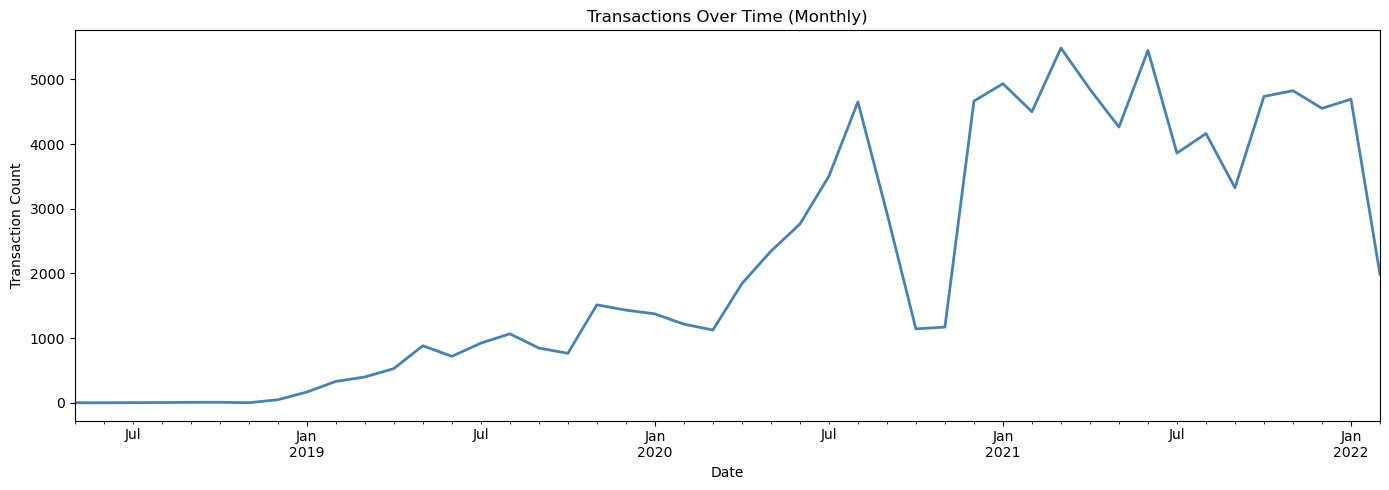

In [4]:
sr_monthly = df.set_index('date').resample('M').size()

fig, ax = plt.subplots(figsize=(14, 5))
sr_monthly.plot(ax=ax, color='steelblue', linewidth=2)
ax.set_title('Transactions Over Time (Monthly)')
ax.set_xlabel('Date')
ax.set_ylabel('Transaction Count')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/date_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### Define Split Points

Using out-of-time split to prevent lookahead bias:
- **Train**: before 2021-06-01 (~70%)
- **Valid**: 2021-06-01 to 2021-11-01 (~15%)
- **Test**: 2021-11-01 onwards (~15%)

In [5]:
dt_valid_start = pd.Timestamp('2021-06-01')
dt_test_start = pd.Timestamp('2021-11-01')

df_train = df[df['date'] < dt_valid_start].copy()
df_valid = df[(df['date'] >= dt_valid_start) & (df['date'] < dt_test_start)].copy()
df_test = df[df['date'] >= dt_test_start].copy()

print(f'Train: {df_train.shape[0]:,} rows ({df_train.shape[0]/len(df)*100:.1f}%)')
print(f'Valid: {df_valid.shape[0]:,} rows ({df_valid.shape[0]/len(df)*100:.1f}%)')
print(f'Test:  {df_test.shape[0]:,} rows ({df_test.shape[0]/len(df)*100:.1f}%)')
print(f'\nTrain: {df_train["date"].min()} to {df_train["date"].max()}')
print(f'Valid: {df_valid["date"].min()} to {df_valid["date"].max()}')
print(f'Test:  {df_test["date"].min()} to {df_test["date"].max()}')

Train: 62,407 rows (62.4%)
Valid: 21,535 rows (21.5%)
Test:  16,058 rows (16.1%)

Train: 2018-05-16 00:00:00 to 2021-05-31 00:00:00
Valid: 2021-06-01 00:00:00 to 2021-10-31 00:00:00
Test:  2021-11-01 00:00:00 to 2022-02-17 00:00:00


#### Verify Distributions

In [6]:
# Price distribution across splits
print('Price Distribution:')
df_price_dist = pd.DataFrame({
    'Train': df_train['price'].describe(),
    'Valid': df_valid['price'].describe(),
    'Test': df_test['price'].describe(),
})
print(df_price_dist.round(2).to_string())

Price Distribution:
           Train      Valid        Test
count   62407.00   21535.00    16058.00
mean      441.62     382.25      633.19
std      3733.66    2956.48    33018.85
min         1.25       0.99        0.99
25%        51.00      34.00       19.50
50%       119.99      76.00       42.99
75%       300.00     200.00      125.00
max    645750.00  198030.00  4006600.00


In [7]:
# Grade distribution across splits
print('Grade Distribution (%):')
df_grade_dist = pd.DataFrame({
    'Train': df_train['grade'].value_counts(normalize=True).sort_index(),
    'Valid': df_valid['grade'].value_counts(normalize=True).sort_index(),
    'Test': df_test['grade'].value_counts(normalize=True).sort_index(),
})
print((df_grade_dist * 100).round(1).to_string())

Grade Distribution (%):
       Train  Valid  Test
grade                    
0.0      0.0    0.0   0.0
1.0      NaN    NaN   0.0
3.0      0.0    NaN   NaN
4.0      0.0    0.0   0.0
5.0      0.0    0.0   0.1
5.5      0.0    NaN   NaN
6.0      0.1    0.2   0.2
6.5      0.0    0.0   NaN
7.0      0.2    0.4   0.4
7.5      0.0    0.1   0.1
8.0      2.3    3.8   3.8
8.5      1.0    0.9   1.0
9.0     33.5   41.4  40.4
9.5     10.1    4.4   4.7
10.0    52.7   48.7  49.4
10.5     0.0    0.0   0.0


In [8]:
# Grading company distribution across splits
print('Grading Company Distribution (%):')
df_gc_dist = pd.DataFrame({
    'Train': df_train['grading_company'].value_counts(normalize=True),
    'Valid': df_valid['grading_company'].value_counts(normalize=True),
    'Test': df_test['grading_company'].value_counts(normalize=True),
})
print((df_gc_dist * 100).round(1).to_string())

Grading Company Distribution (%):
                 Train  Valid  Test
grading_company                    
BGS               16.2    7.9   7.9
PSA               83.8   92.1  90.8
SGC                NaN    0.0   1.3


#### Visualize Splits

/tmp/ipykernel_18646/2174601969.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sr_monthly = df_split.set_index('date').resample('M').size()
/tmp/ipykernel_18646/2174601969.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sr_monthly = df_split.set_index('date').resample('M').size()
/tmp/ipykernel_18646/2174601969.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sr_monthly = df_split.set_index('date').resample('M').size()


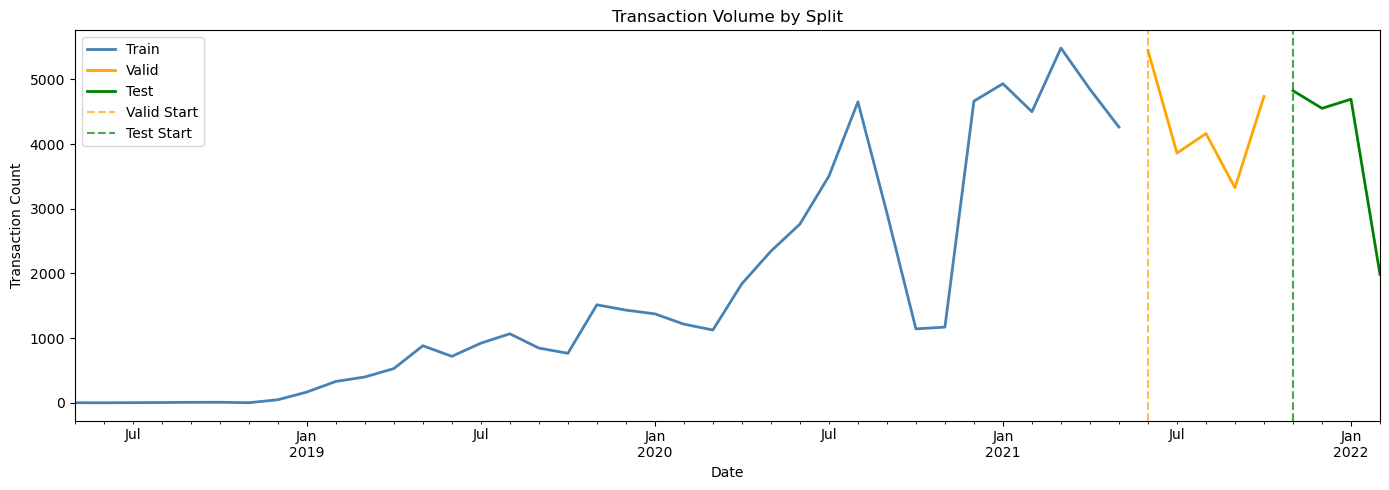

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

for str_label, df_split, str_color in [('Train', df_train, 'steelblue'),
                                         ('Valid', df_valid, 'orange'),
                                         ('Test', df_test, 'green')]:
    sr_monthly = df_split.set_index('date').resample('M').size()
    sr_monthly.plot(ax=ax, color=str_color, linewidth=2, label=str_label)

ax.axvline(dt_valid_start, color='orange', linestyle='--', alpha=0.7, label='Valid Start')
ax.axvline(dt_test_start, color='green', linestyle='--', alpha=0.7, label='Test Start')
ax.set_title('Transaction Volume by Split')
ax.set_xlabel('Date')
ax.set_ylabel('Transaction Count')
ax.legend()
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### Save to S3

In [10]:
%%time
for str_name, df_split in [('train', df_train), ('valid', df_valid), ('test', df_test)]:
    str_s3_path = f's3://{str_bucket}/{str_task}/{str_name}.csv'
    df_split.to_csv(str_s3_path, index=False)
    print(f'Saved {str_name}.csv to {str_s3_path} ({df_split.shape})')

Saved train.csv to s3://assessment-alt/03_data_split/train.csv ((62407, 9))
Saved valid.csv to s3://assessment-alt/03_data_split/valid.csv ((21535, 9))
Saved test.csv to s3://assessment-alt/03_data_split/test.csv ((16058, 9))
CPU times: user 680 ms, sys: 18.2 ms, total: 698 ms
Wall time: 926 ms


#### Takeaways

- **Out-of-time split** used to prevent lookahead bias — critical for time-series pricing data
- **Train/Valid/Test** roughly 70/15/15 split by date
- **Price distributions** are similar across splits, though median prices may shift over time due to market trends
- **Grade and grading company distributions** are relatively stable across splits
- Temporal split means the model must generalize to future market conditions, not just unseen random samples